June 29th  
Now try to simulate the Delta7 network using the average recurrent connectivity profile. Unlike the other notebook, this notebook keeps within glomerular connections, but scales them with a different factor compared to between glomerulus connections.

Need to go through and comment, but look at simulate_using_avg_profile_1 for comments

In [1]:
import sys, os, glob
import datetime, time

import numpy as np
from numpy import linalg as nla
import scipy.linalg as sla
import numpy.random as nrd

# import scipy.stats as sst

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

gen_fns_dir = os.path.abspath('../shared')
sys.path.append(gen_fns_dir)
from general_file_fns import load_pickle_file, save_pickle_file
import conn_data_analysis_fns as cdaf

curr_date=datetime.datetime.now().strftime('%Y_%m_%d')+'_'
#sd=int((time.time()%1)*(2**31))
# rng = nrd.default_rng(sd)
# print('Seed= ',sd)

In [2]:
data_path = '../delta7_rec_matrices/'
fname = 'delta7_delta7_average_profiles.p'
conn = load_pickle_file(data_path + fname)
print(conn.keys())

dict_keys(['subtype_list', 'neuron_list', 'subtype_idx', 'subtype_boundaries', 'raw_conn_matrix', 'norm_conn_matrix', 'subtype_rec_matrix', 'subtype_avg_input', 'subtype_avg_output', 'left_glom_list', 'right_glom_list', 'left_glom_idx', 'right_glom_idx', 'left_glom_rec_matrix', 'left_glom_avg_input', 'left_glom_avg_output', 'right_glom_rec_matrix', 'right_glom_avg_input', 'right_glom_avg_output', 'glom_avg_input', 'glom_avg_output', 'n_gloms'])


In [3]:
n_gloms = conn['n_gloms']
glom_avg_input = conn['glom_avg_input']
glom_avg_output = conn['glom_avg_output']

In [4]:
glom_avg_input

array([0.15486901, 0.15601156, 0.11619277, 0.08521092, 0.13174347,
       0.08732954, 0.11803541, 0.15060732])

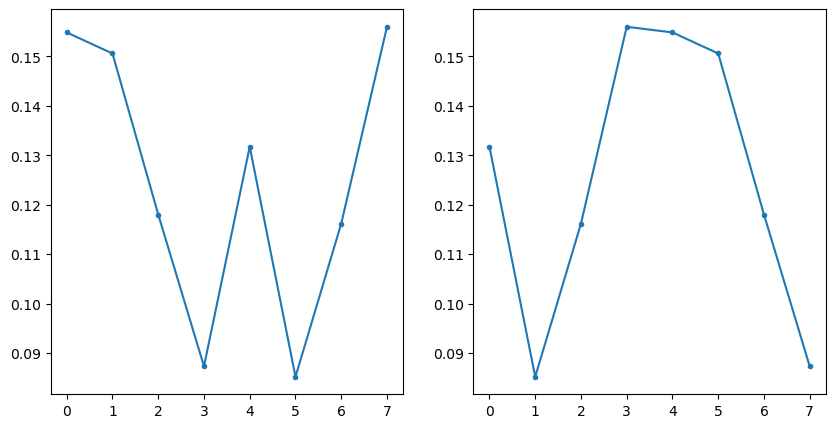

In [5]:
first_col = np.roll(glom_avg_output, -4)
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(glom_avg_output, marker='.')
ax[1].plot(first_col, marker='.')

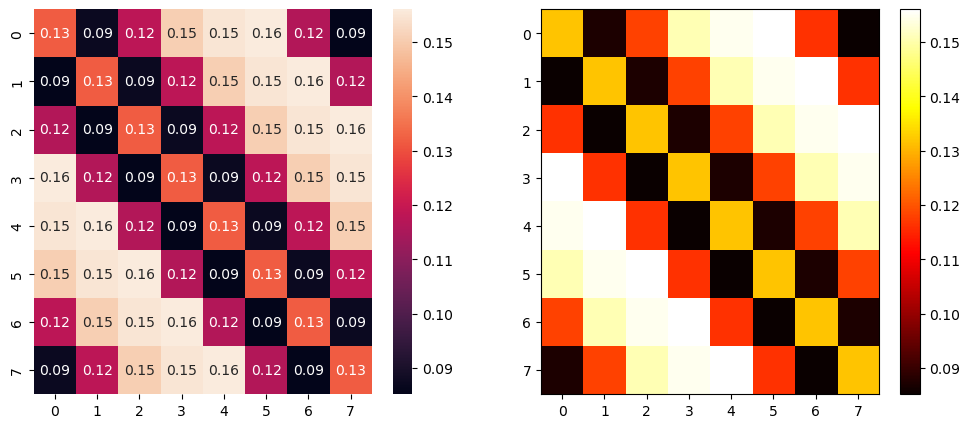

In [6]:
W = sla.circulant(first_col)

fig, ax = plt.subplots(1,2,figsize=(12, 5))
sns.heatmap(W, cmap="rocket", annot=True, fmt=".2f", ax=ax[0])
# ax[0].invert_yaxis()
p = ax[1].imshow(W, aspect='auto', interpolation='nearest', cmap='hot')
fig.colorbar(p, ax=ax[1])



In [7]:
np.allclose(W[:,0], first_col)

True

In [8]:
def relu(x):
    '''Returns 0 if x<0 and x otherwise'''
    return np.maximum(x, 0)

def simulate_network(W, b, x0, time_to_run, dt):
    '''Simulate the network using Euler's method.
    Inputs:
    W:             N x N connectivity matrix
    x0:            N-dimensional initial condition
    time_to_run    how long to simulate for
    dt             simulation step size
    
    Returns an n_times x N matrix containing the simulated system. Note
    that each row is a time point and each column a neuron. 
    '''
    
    n_steps = np.round(time_to_run / dt).astype(int)
    N = W.shape[0] # Number of neurons
    
    # We'll store outputs here
    x = np.zeros((n_steps + 1, N))
    x[0] = np.array(x0)
    
    for i in range(1, n_steps + 1):
        x[i] = x[i-1] + dt * (-x[i-1] + relu(W @ x[i-1] + b))
    
    t = dt * np.arange(n_steps + 1) # Make the time points too for plotting
    return x, t
    

In [9]:
np.diagonal(W)

array([0.13174347, 0.13174347, 0.13174347, 0.13174347, 0.13174347,
       0.13174347, 0.13174347, 0.13174347])

In [10]:
# alpha converts within glomerulus connection counts to strength, while beta does
# the same for cross glomerular connections. b is a background bias or excitability
alpha = -1
beta = -6
b = 25

W_rec = beta * W
np.fill_diagonal(W_rec, alpha*np.diagonal(W).copy())

In [11]:
# beta = -8, b=25 gives 3 glom wide bump
x0 = np.array([10, 5, 2, 0, 0, 0, 2, 5.])
x0 = np.roll(x0, 3)
time_to_run = 100.
dt = 0.05

x, t = simulate_network(W_rec, b, x0, time_to_run, dt)

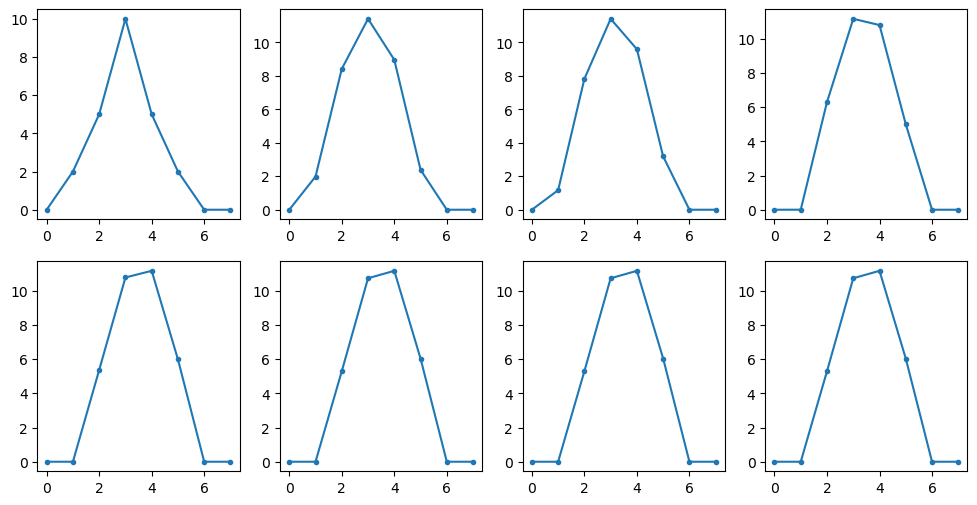

In [12]:
# time_points = np.array([0, 1, 2, 3, 4, 5, 6, 6.9])
time_points = np.array([0, 10, 20, 30, 50, 80, 90, 99])
time_idx = np.round(time_points/dt).astype(int)
fig, axes = plt.subplots(2,4,figsize=(12,6))
for tid, ax in zip(time_idx, axes.flatten()):
    ax.plot(x[tid], marker='.')
    

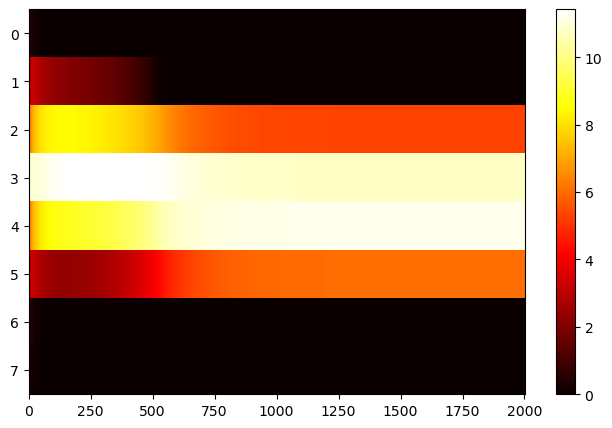

In [13]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
# sns.heatmap(x.T, cmap="rocket")
p = ax.imshow(x.T, aspect='auto', interpolation='nearest', cmap='hot')
fig.colorbar(p, ax=ax)


In [14]:
W_rec @ x[-1] + b

array([-4.49916148, -1.09642814,  5.29981818, 10.74102781, 11.17593518,
        6.04107507, -0.8589871 , -4.44289023])